In [403]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

## 1. Problem Formulation & Scoping
### Predicting Laptop Price 
- Use Regressing Technique


## 2. Data Collection
- We have dataset : laptop_data.csv

## 3. Reading & Understanding Data
- Load dataset (pandas, numpy).
- Check df.head(), df.info(), df.shape, df.describe() to get a feel for it.
- Identify data types (numeric, categorical, text, dates).


In [404]:
df = pd.read_csv("laptop_data.csv")

df.head() # show first 5 rows
# df.tail() # show last 5 rows 

,Brand,RAM,Storage,Weight,Screen Size,Battery Life (hours),Operating System,CPU,GPU,Build Quality,Display Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Pre-Installed Softwares,Price
0,Apple,32.0,1024.0,2.67,13.3,8,macOS,Apple M1,Apple Integrated,Excellent,Full HD,3,Yes,Yes,No,Grey,2.0,2145.6
1,Lenovo,32.0,256.0,2.03,13.3,6,macOS,Intel i7,Intel Integrated,Poor,4K,2,Yes,Yes,Yes,Black,3.0,1633.4
2,Dell,8.0,512.0,1.30,17.0,4,macOS,Intel i9,NVIDIA RTX 4060,Good,Full HD,1,NaN,Yes,No,NaN,4.0,1619.8
3,Apple,8.0,1024.0,2.05,14.0,10,NaN,Apple M1,Apple Integrated,Fair,NaN,1,No,Yes,Yes,Grey,1.0,1724.6
4,Dell,NaN,512.0,1.43,17.0,8,Windows,AMD Ryzen 5,NVIDIA RTX 4060,Poor,4K,3,Yes,Yes,Yes,Blue,2.0,1707.8


#### check rows and columns

In [405]:
df.shape 

(50, 18)

#### Get Columns Name

In [406]:
df.columns

Index(['Brand', 'RAM', 'Storage', 'Weight', 'Screen Size',
       'Battery Life (hours)', 'Operating System', 'CPU', 'GPU',
       'Build Quality', 'Display Quality', 'Warranty', 'Touchscreen',
       'Backlit', 'Fingerprint', 'Color', 'Pre-Installed Softwares', 'Price'],
      dtype='object')

#### df.info()
The df.info() method in the pandas library for Python provides a concise summary of a DataFrame

In [407]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Brand                    50 non-null     object 
 1   RAM                      45 non-null     float64
 2   Storage                  47 non-null     float64
 3   Weight                   46 non-null     float64
 4   Screen Size              47 non-null     float64
 5   Battery Life (hours)     50 non-null     int64  
 6   Operating System         45 non-null     object 
 7   CPU                      46 non-null     object 
 8   GPU                      45 non-null     object 
 9   Build Quality            45 non-null     object 
 10  Display Quality          46 non-null     object 
 11  Warranty                 50 non-null     int64  
 12  Touchscreen              44 non-null     object 
 13  Backlit                  47 non-null     object 
 14  Fingerprint              44 

## 4. EDA (Exploratory Data Analysis) & Handling Missing Values
- Visualize distributions (hist, boxplot, pairplot).
- Detect missing values (df.isnull().sum()), outliers, skewness.
- Handle missing values by:
- Drop (if very few rows missing).
- Impute (mean, median, mode, forward fill).

### Replacing Col Replace spaces with underscores

In [408]:
df.columns = df.columns.str.replace(" ", "_")

#### df.isnull().sum()
Check for missing values

In [409]:
df.isnull().sum()

Brand                      0
RAM                        5
Storage                    3
Weight                     4
Screen_Size                3
Battery_Life_(hours)       0
Operating_System           5
CPU                        4
GPU                        5
Build_Quality              5
Display_Quality            4
Warranty                   0
Touchscreen                6
Backlit                    3
Fingerprint                6
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

### Handling Missing Values 

When handling missing values, the choice between mean, median, or mode depends on data type and distribution.

##### ✅ Rule of Thumb
1. Numerical, Normal → Mean
2. Numerical, Skewed → Median
3. Categorical → Mode
4. Binary (Yes/No) → Mode (or 0/1 average)

##### 🔎 How to interpret results:

- If skewness ≈ 0 (between -0.5 and 0.5): distribution is almost normal → use Mean.
- If skewness is large (+ve or -ve): distribution is skewed → use Median.
- If column is categorical-like (fixed values: 4, 8, 16, 32, etc.): better to use Mode.

### Handling Missing Values from (RAM)

In [410]:
df["RAM"].head(7)

0    32.0
1    32.0
2     8.0
3     8.0
4     NaN
5    32.0
6     8.0
Name: RAM, dtype: float64

Mean: 15.377777777777778
Median: 8.0
Mode: 32.0
Skewness: 0.5725939073071016


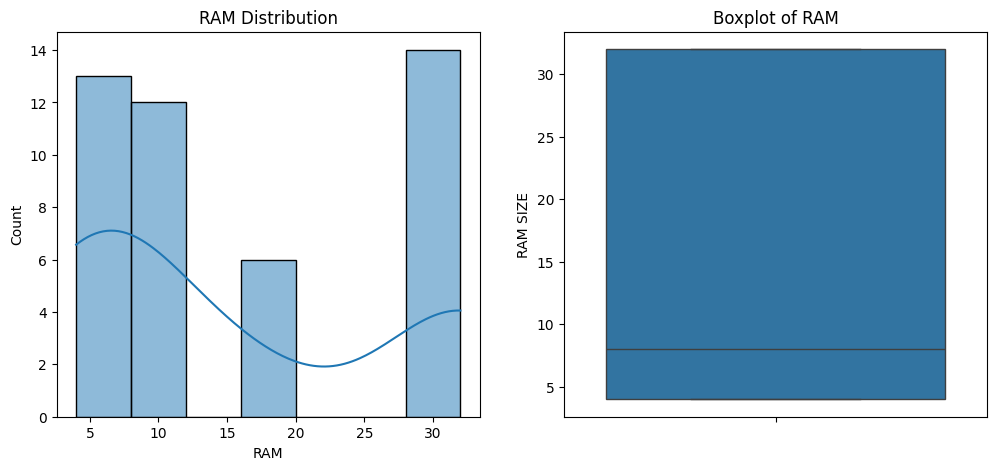

In [411]:
# 1. Basic summary
print("Mean:", df["RAM"].mean())
print("Median:", df["RAM"].median())
print("Mode:", df["RAM"].mode()[0])   # mode() returns a Series, so take [0]

# 2. Skewness (to check symmetry of distribution)
print("Skewness:", df["RAM"].skew())


plt.figure(figsize=(12,5))

# 3. Distribution plot
plt.subplot(1,2,1)
sns.histplot(df["RAM"], kde=True)
plt.title("RAM Distribution")


# 4. Boxplot
plt.subplot(1,2,2)
sns.boxplot(df["RAM"])
plt.ylabel("RAM SIZE")
plt.title("Boxplot of RAM")


plt.show()


Before Imputation (with NaNs):
0     32.0
1     32.0
2      8.0
3      8.0
4      NaN
5     32.0
6      8.0
7     16.0
8      4.0
9     32.0
10     4.0
11     4.0
Name: RAM, dtype: float64


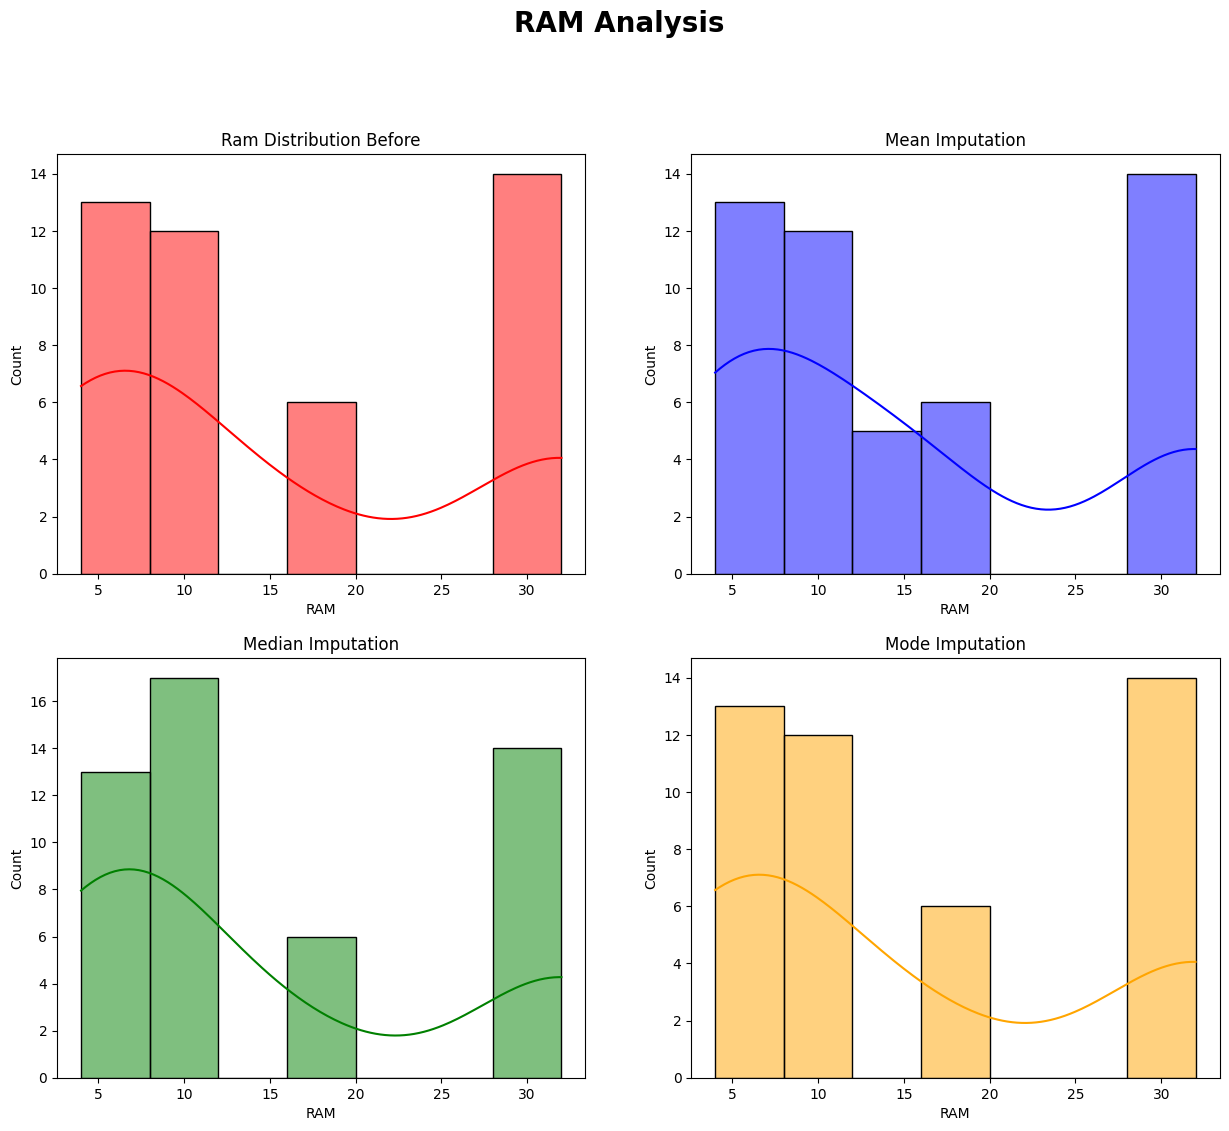

Mean value used for imputation: 15.377777777777778
Median value used for imputation: 8.0
Mode value used for imputation: 0    32.0
Name: RAM, dtype: float64


In [412]:

# Copy the RAM column
ram = df["RAM"]

# ram.iloc[[2, 10, 20]] = np.nan   # inject NaNs

print("Before Imputation (with NaNs):")
print(ram.head(12))

# Impute with Mean
ram_mean = ram.fillna(ram.mean())

# Impute with Median
ram_median = ram.fillna(ram.median())
# Impute with Mode
ram_mode = ram.fillna(ram.mode())

# Plot comparison
plt.figure(figsize=(15,12))
plt.suptitle(
    "RAM Analysis",
    fontsize=20,
    fontweight="bold",
    y=1  # adjust position above plots
)



plt.subplot(2,2,1)
sns.histplot(ram, kde=True, color="red")
plt.title("Ram Distribution Before")


plt.subplot(2,2,2)
sns.histplot(ram_mean, kde=True, color="blue")
plt.title("Mean Imputation")

plt.subplot(2,2,3)
sns.histplot(ram_median, kde=True, color="green")
plt.title("Median Imputation")

plt.subplot(2,2,4)
sns.histplot(ram_mode, kde=True, color="orange")
plt.title("Mode Imputation")

plt.show()

print("Mean value used for imputation:", ram.mean())
print("Median value used for imputation:", ram.median())
print("Mode value used for imputation:", ram.mode())

##### 🔎 What you’ll see:

- Mean Imputation → The filled values will slightly pull the distribution towards the right tail (since mean > median in right-skewed data).

- Median Imputation → The filled values won’t distort the shape much and will keep the distribution closer to original.

👉 That’s why Median is preferred here for missing RAM values.

###  Fill missing values with median

In [413]:
df["RAM"].head(7)

0    32.0
1    32.0
2     8.0
3     8.0
4     NaN
5    32.0
6     8.0
Name: RAM, dtype: float64

In [414]:
ram_med = df["RAM"].median()
print(ram_med)

8.0


In [415]:
df["RAM"].fillna(ram_med, inplace=True) # inplace=True This modifies the DataFrame directly, no need to reassign.

In [416]:
df["RAM"].head(7)

0    32.0
1    32.0
2     8.0
3     8.0
4     8.0
5    32.0
6     8.0
Name: RAM, dtype: float64

In [417]:
df["RAM"].isnull().sum() 

np.int64(0)

### Handling Missing Values (Storage)

In [418]:
print(f"Total Missing Values: {df.Storage.isnull().sum()}")
print(df["Storage"].head(10))

Total Missing Values: 3
0    1024.0
1     256.0
2     512.0
3    1024.0
4     512.0
5     512.0
6     256.0
7    1024.0
8       NaN
9    1024.0
Name: Storage, dtype: float64


Storage Mean: 985.8723404255319
Storage Median: 512.0
Storage Mode: 2048.0
Skewness of Storage: 0.5770667557544393


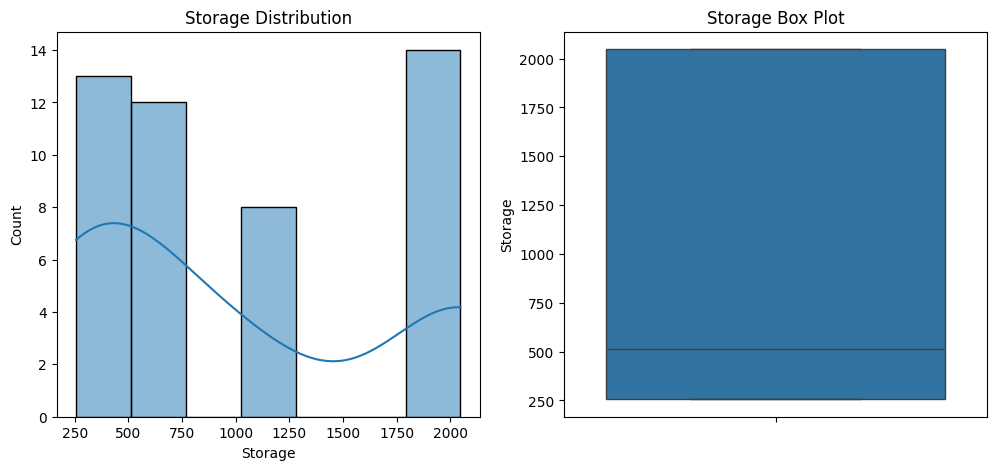

In [419]:
print(f"Storage Mean: {df.Storage.mean()}")
print(f"Storage Median: {df.Storage.median()}")
print(f"Storage Mode: {df.Storage.mode()[0]}")
print(f"Skewness of Storage: {df.Storage.skew()}")


plt.figure(figsize=(12,5))

# Distribution
plt.subplot(1,2,1)
sns.histplot(df.Storage, kde=True)
plt.title("Storage Distribution")

# Boxplot for Outliers
plt.subplot(1,2,2)
sns.boxplot(df.Storage)
plt.title('Storage Box Plot')

plt.show()

Before Imputation (with NaNs):
0     1024.0
1      256.0
2      512.0
3     1024.0
4      512.0
5      512.0
6      256.0
7     1024.0
8        NaN
9     1024.0
10    2048.0
11     256.0
Name: Storage, dtype: float64


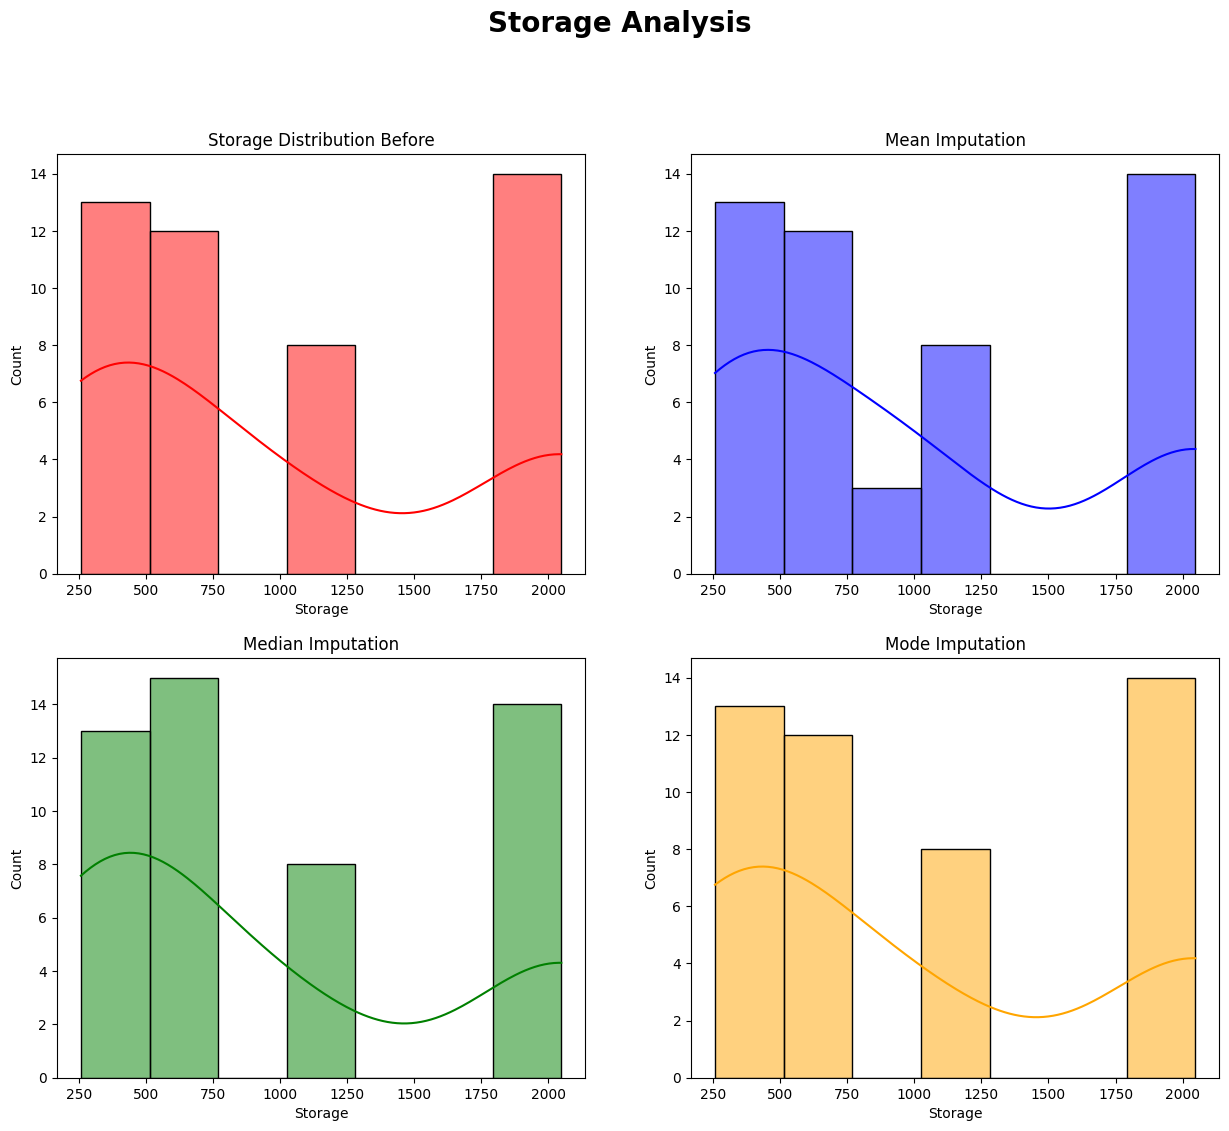

Mean value used for imputation: 985.8723404255319
Median value used for imputation: 512.0
Mode value used for imputation: 0    2048.0
Name: Storage, dtype: float64


In [420]:

# Copy the RAM column
disk = df["Storage"]

# ram.iloc[[2, 10, 20]] = np.nan   # inject NaNs

print("Before Imputation (with NaNs):")
print(disk.head(12))

# Impute with Mean
disk_mean = disk.fillna(disk.mean())

# Impute with Median
disk_median = disk.fillna(disk.median())
# Impute with Mode
disk_mode = disk.fillna(disk.mode())

# Plot comparison
plt.figure(figsize=(15,12))
plt.suptitle(
    "Storage Analysis",
    fontsize=20,
    fontweight="bold",
    y=1  # adjust position above plots
)



plt.subplot(2,2,1)
sns.histplot(disk, kde=True, color="red")
plt.title("Storage Distribution Before")


plt.subplot(2,2,2)
sns.histplot(disk_mean, kde=True, color="blue")
plt.title("Mean Imputation")

plt.subplot(2,2,3)
sns.histplot(disk_median, kde=True, color="green")
plt.title("Median Imputation")

plt.subplot(2,2,4)
sns.histplot(disk_mode, kde=True, color="orange")
plt.title("Mode Imputation")

plt.show()

print("Mean value used for imputation:", disk.mean())
print("Median value used for imputation:", disk.median())
print("Mode value used for imputation:", disk.mode())

### Filling Missing Values with (Median)

In [421]:
df.Storage.head(10)

0    1024.0
1     256.0
2     512.0
3    1024.0
4     512.0
5     512.0
6     256.0
7    1024.0
8       NaN
9    1024.0
Name: Storage, dtype: float64

In [422]:
disk_median = df["Storage"].median()
print(disk_median)

512.0


In [423]:
df["Storage"].fillna(disk_median, inplace=True)

In [424]:
df["Storage"].head(10)

0    1024.0
1     256.0
2     512.0
3    1024.0
4     512.0
5     512.0
6     256.0
7    1024.0
8     512.0
9    1024.0
Name: Storage, dtype: float64

In [425]:
df.Storage.isnull().sum()

np.int64(0)

### Handling Missing Values for (Weight)

In [426]:
df["Weight"].head(7)

0    2.67
1    2.03
2    1.30
3    2.05
4    1.43
5    1.90
6     NaN
Name: Weight, dtype: float64

In [427]:
df["Weight"].isnull().sum()

np.int64(4)

In [428]:
df["Weight"].dtype

dtype('float64')

Weight Mean: 1.9715217391304347
Weight Median: 1.915
Weight Mode: 1.06
Skewness of Weight: 0.22318626641915712


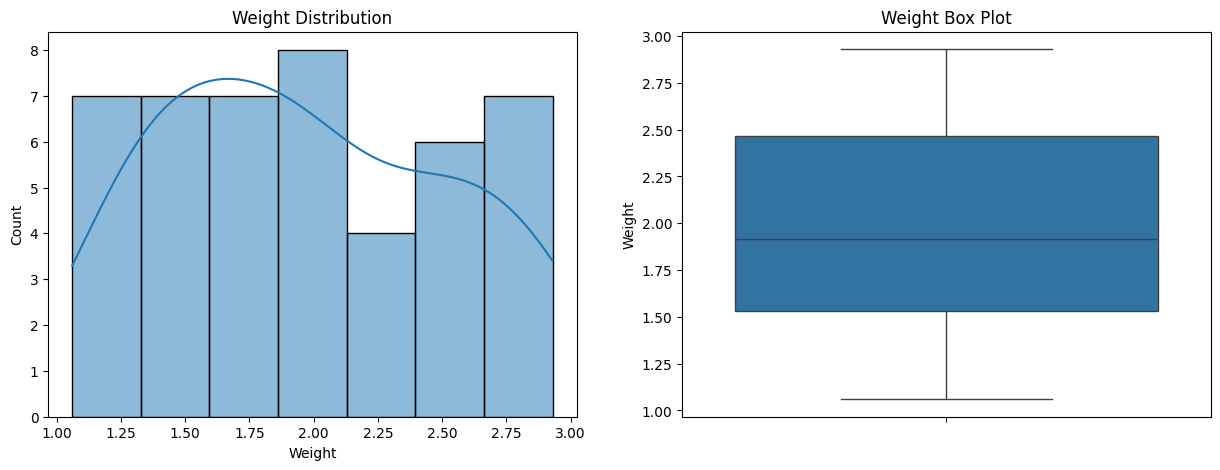

In [429]:

print(f"Weight Mean: {df.Weight.mean()}")
print(f"Weight Median: {df.Weight.median()}")
print(f"Weight Mode: {df.Weight.mode()[0]}")

print(f"Skewness of Weight: {df.Weight.skew()}")


plt.figure(figsize=(15,5))

# Distribution
plt.subplot(1,2,1)
sns.histplot(df.Weight, kde=True)
plt.title("Weight Distribution")

# Boxplot for Outliers
plt.subplot(1,2,2)
sns.boxplot(df.Weight)
plt.title('Weight Box Plot')

plt.show()

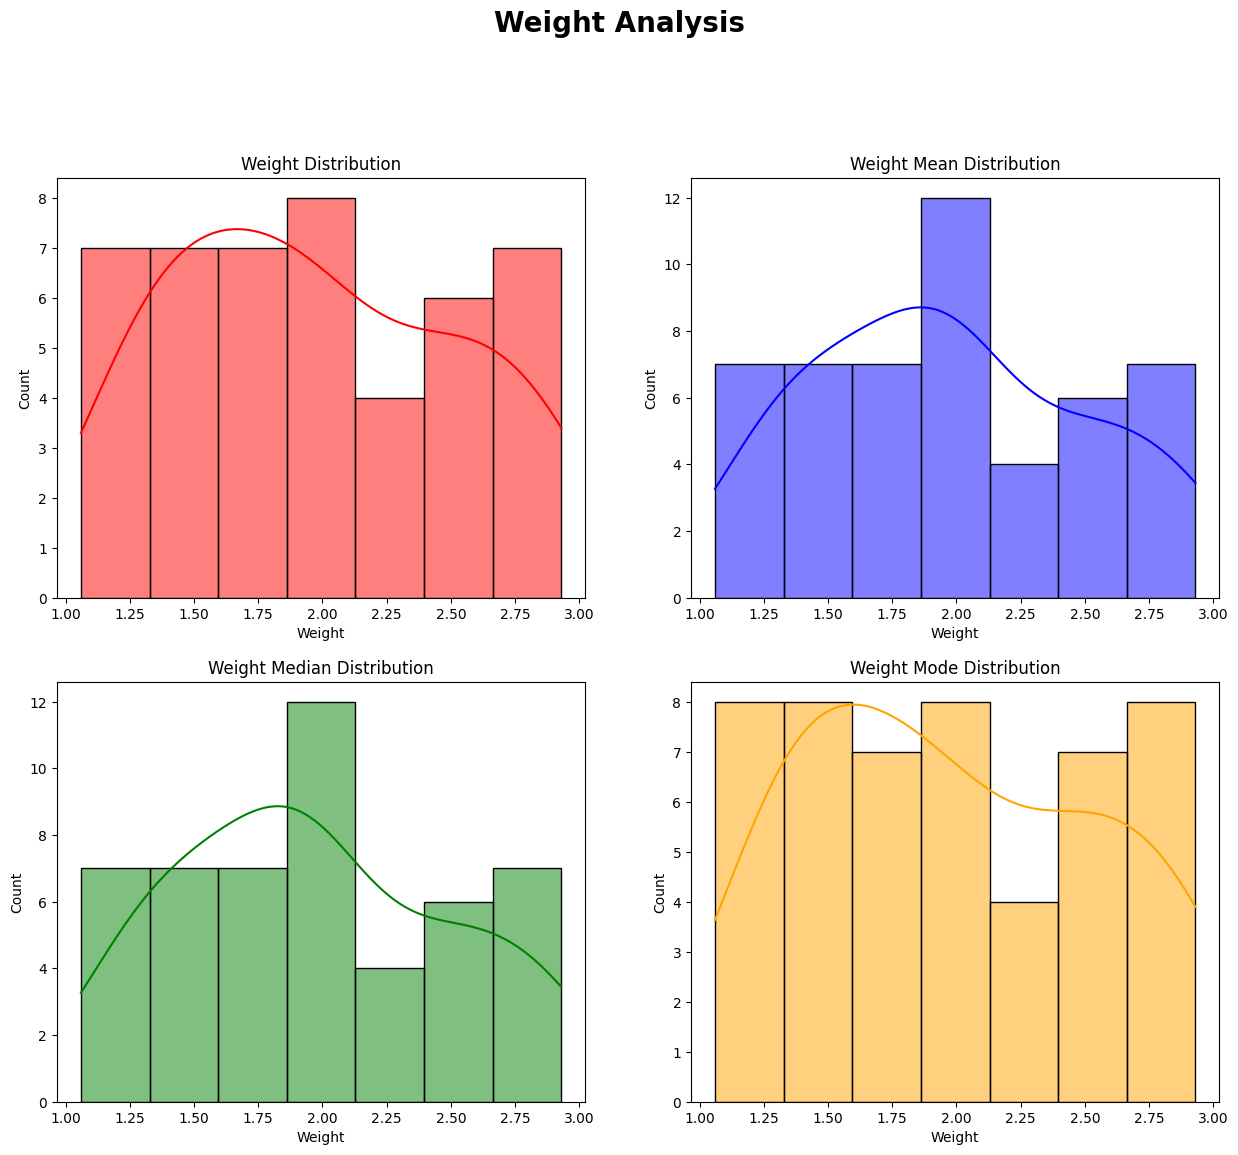

Mean value used for imputation: 1.9715217391304347
Median value used for imputation: 1.915
Mode value used for imputation: 1.06


In [430]:
weight = df["Weight"]
# weight_mean = weight.mean()
weight_mean = weight.fillna(weight.mean())
weight_med = weight.fillna(weight.median())
weight_mode = weight.fillna(weight.mode())

# Ploting

plt.figure(figsize=(15,12))
# Main title for the entire figure
plt.suptitle(
    "Weight Analysis",
    fontsize=20,
    fontweight="bold",
    y=1.02  # adjust position above plots
)

# 
plt.subplot(2,2,1)
sns.histplot(weight, color="red", kde=True)
plt.title("Weight Distribution")

# 
plt.subplot(2,2,2)
sns.histplot(weight_mean, color="blue", kde=True)
plt.title("Weight Mean Distribution")


# 
plt.subplot(2,2,3)
sns.histplot(weight_med, color="green", kde=True)
plt.title("Weight Median Distribution")

# 
plt.subplot(2,2,4)
sns.histplot(weight_mode, color="Orange", kde=True)
plt.title("Weight Mode Distribution")

plt.show()

print("Mean value used for imputation:", weight.mean())
print("Median value used for imputation:", weight.median())
print("Mode value used for imputation:", weight.mode()[0])

### Filling Missing Values with (median)

In [431]:
df.Weight.head(7)

0    2.67
1    2.03
2    1.30
3    2.05
4    1.43
5    1.90
6     NaN
Name: Weight, dtype: float64

In [432]:
df.Weight.isnull().sum()

np.int64(4)

In [433]:
weight_med = df["Weight"].median()
print(weight_med)

1.915


In [434]:
df["Weight"].fillna(weight_med,inplace=True)

In [435]:
df.Weight.head(7)

0    2.670
1    2.030
2    1.300
3    2.050
4    1.430
5    1.900
6    1.915
Name: Weight, dtype: float64

In [436]:
df.Weight.isnull().sum()

np.int64(0)

### Checking

In [437]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                3
Battery_Life_(hours)       0
Operating_System           5
CPU                        4
GPU                        5
Build_Quality              5
Display_Quality            4
Warranty                   0
Touchscreen                6
Backlit                    3
Fingerprint                6
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

### Handling Missing Values for (Screen Size)

In [438]:
df.Screen_Size.iloc[20:25] # bw 20-25

20    15.6
21     NaN
22    13.3
23    17.0
24    15.6
Name: Screen_Size, dtype: float64

Screen Size Mean: 14.69148936170213
Screen Size Median: 14.0
Screen Size Mode: 13.3
Skewness of Screen_Size: 0.5951731598969511


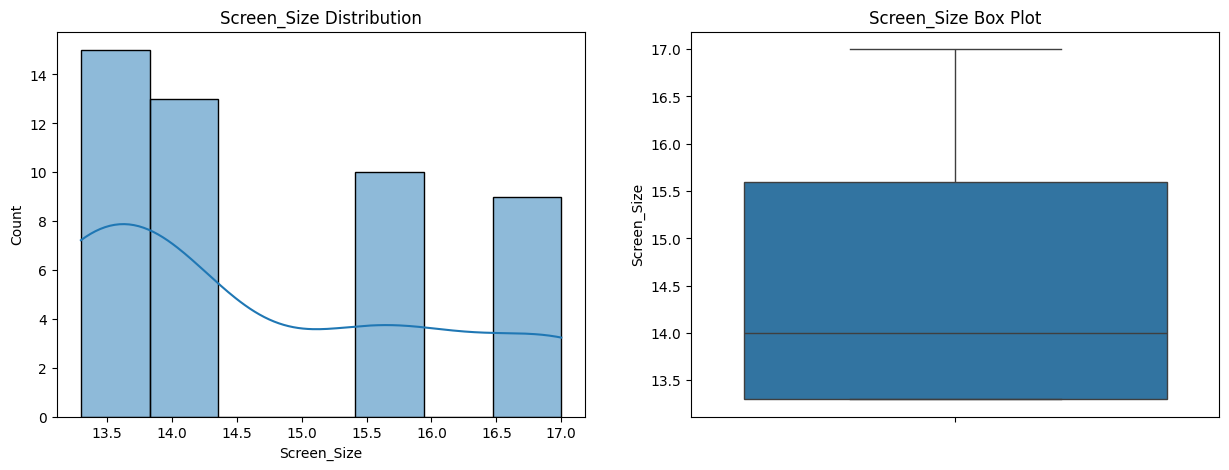

In [439]:

print(f"Screen Size Mean: {df.Screen_Size.mean()}")
print(f"Screen Size Median: {df.Screen_Size.median()}")
print(f"Screen Size Mode: {df.Screen_Size.mode()[0]}")

print(f"Skewness of Screen_Size: {df.Screen_Size.skew()}")


plt.figure(figsize=(15,5))

# Distribution
plt.subplot(1,2,1)
sns.histplot(df.Screen_Size, kde=True)
plt.title("Screen_Size Distribution")

# Boxplot for Outliers
plt.subplot(1,2,2)
sns.boxplot(df.Screen_Size)
plt.title('Screen_Size Box Plot')

plt.show()

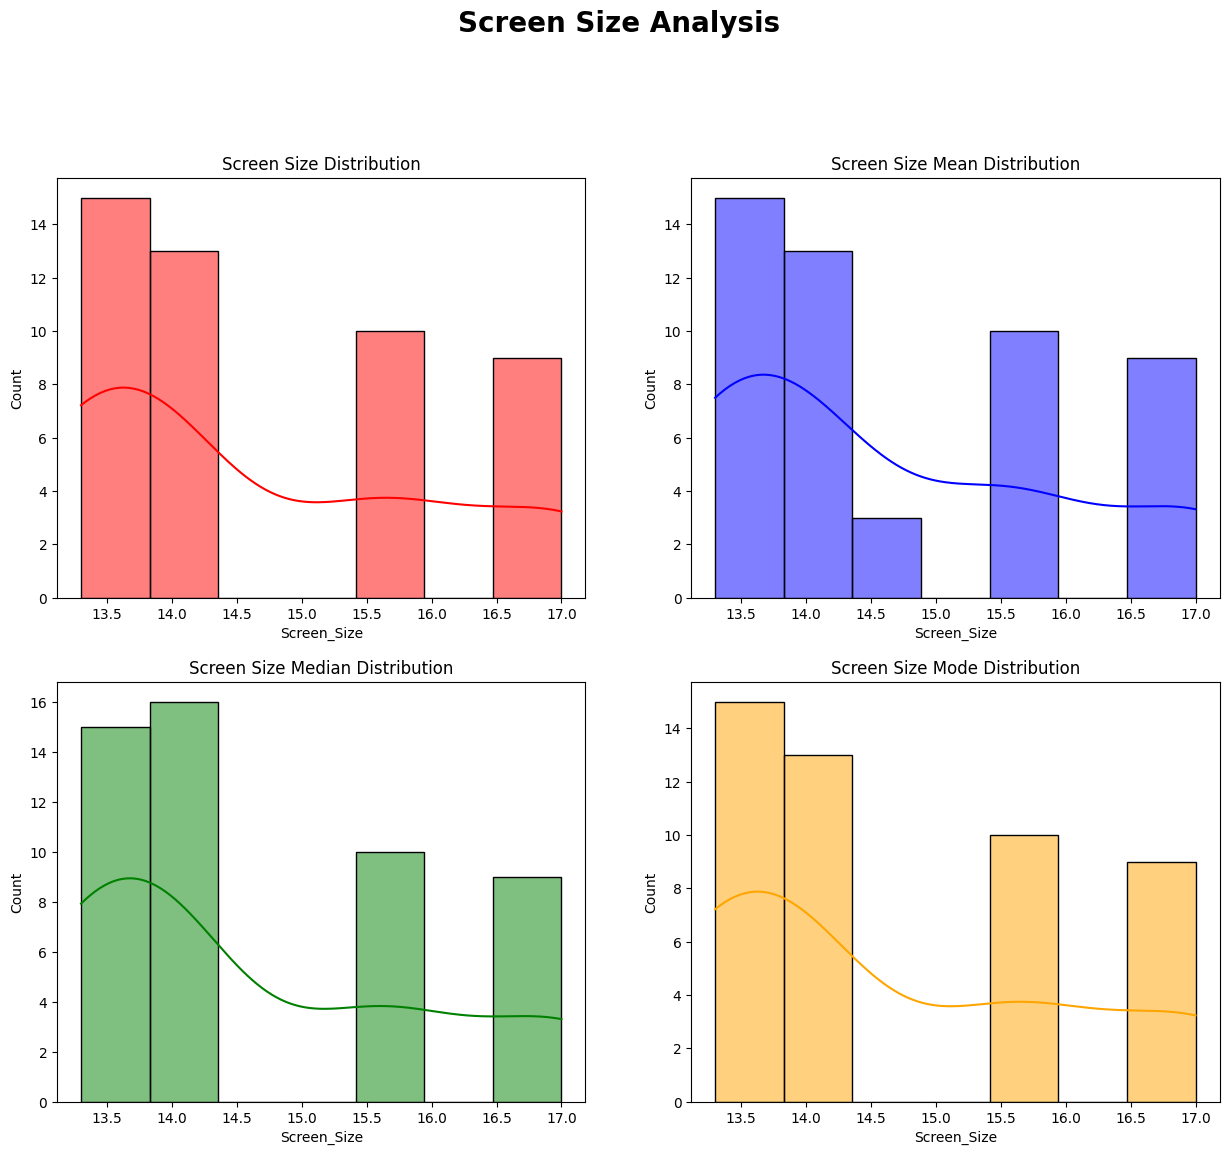

Mean value used for imputation: 14.69148936170213
Median value used for imputation: 14.0
Mode value used for imputation: 13.3


In [440]:
screenSize = df["Screen_Size"]
# weight_mean = weight.mean()
screenSize_mean = screenSize.fillna(screenSize.mean())
screenSize_med = screenSize.fillna(screenSize.median())
screenSize_mode = screenSize.fillna(screenSize.mode())

# Ploting

plt.figure(figsize=(15,12))
# Main title for the entire figure
plt.suptitle(
    "Screen Size Analysis",
    fontsize=20,
    fontweight="bold",
    y=1.02  # adjust position above plots
)

# 
plt.subplot(2,2,1)
sns.histplot(screenSize, color="red", kde=True)
plt.title("Screen Size Distribution")

# 
plt.subplot(2,2,2)
sns.histplot(screenSize_mean, color="blue", kde=True)
plt.title("Screen Size Mean Distribution")


# 
plt.subplot(2,2,3)
sns.histplot(screenSize_med, color="green", kde=True)
plt.title("Screen Size Median Distribution")

# 
plt.subplot(2,2,4)
sns.histplot(screenSize_mode, color="Orange", kde=True)
plt.title("Screen Size Mode Distribution")

plt.show()

print("Mean value used for imputation:", screenSize.mean())
print("Median value used for imputation:", screenSize.median())
print("Mode value used for imputation:", screenSize.mode()[0])

### Filling with Median

In [441]:
screen_s_med = df["Screen_Size"].median()
print(screen_s_med)

14.0


In [442]:
df["Screen_Size"].fillna(screen_s_med, inplace=True)

In [443]:
df["Screen_Size"].iloc[20:25]

20    15.6
21    14.0
22    13.3
23    17.0
24    15.6
Name: Screen_Size, dtype: float64

In [444]:
df["Screen_Size"].isnull().sum()

np.int64(0)

### Handling Missing Values for (Operating_System)

In [445]:
df["Operating_System"].head()

0      macOS
1      macOS
2      macOS
3        NaN
4    Windows
Name: Operating_System, dtype: object

In [446]:
df["Operating_System"].isnull().sum()

np.int64(5)

In [447]:

print(df["Operating_System"].mode())

0    macOS
Name: Operating_System, dtype: object


Operating_System Mode: macOS


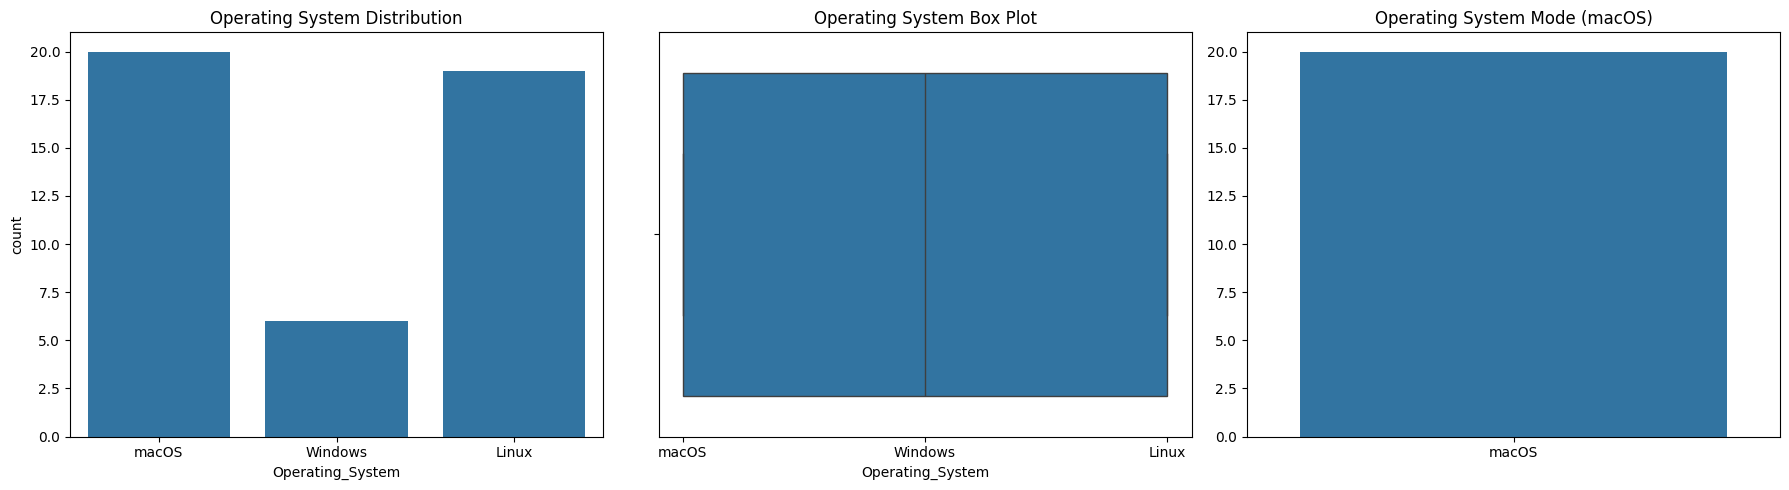

In [448]:

## Operating_System is categorical data can only measure mode
print(f"Operating_System Mode: {df.Operating_System.mode()[0]}")

# print(f"Skewness of Screen_Size: {df.Operating_System.skew()}") #  could not convert string to float: 'macOS'

plt.figure(figsize=(18,5))

# 1. Distribution (Countplot since OS is categorical)
plt.subplot(1,3,1)
sns.countplot(x=df["Operating_System"])
plt.title("Operating System Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(1,3,2)
sns.boxplot(x=df["Operating_System"])
plt.title("Operating System Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(1,3,3)
mode_val = df["Operating_System"].mode()[0]
sns.barplot(x=[mode_val], y=[df["Operating_System"].value_counts()[mode_val]])
plt.title(f"Operating System Mode ({mode_val})")

plt.tight_layout()
plt.show()


In [449]:
os_mode = df["Operating_System"].mode()[0]

os_mode

'macOS'

In [450]:
df["Operating_System"].fillna(os_mode,inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\3217314099.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Operating_System"].fillna(os_mode,inplace=True)


In [451]:
df["Operating_System"].isnull().sum()

np.int64(0)

In [452]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        4
GPU                        5
Build_Quality              5
Display_Quality            4
Warranty                   0
Touchscreen                6
Backlit                    3
Fingerprint                6
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Handling Missing Values (CPU)

In [453]:
df["CPU"].head()

0       Apple M1
1       Intel i7
2       Intel i9
3       Apple M1
4    AMD Ryzen 5
Name: CPU, dtype: object

In [454]:
df["CPU"].mode()[0]

'Apple M1'

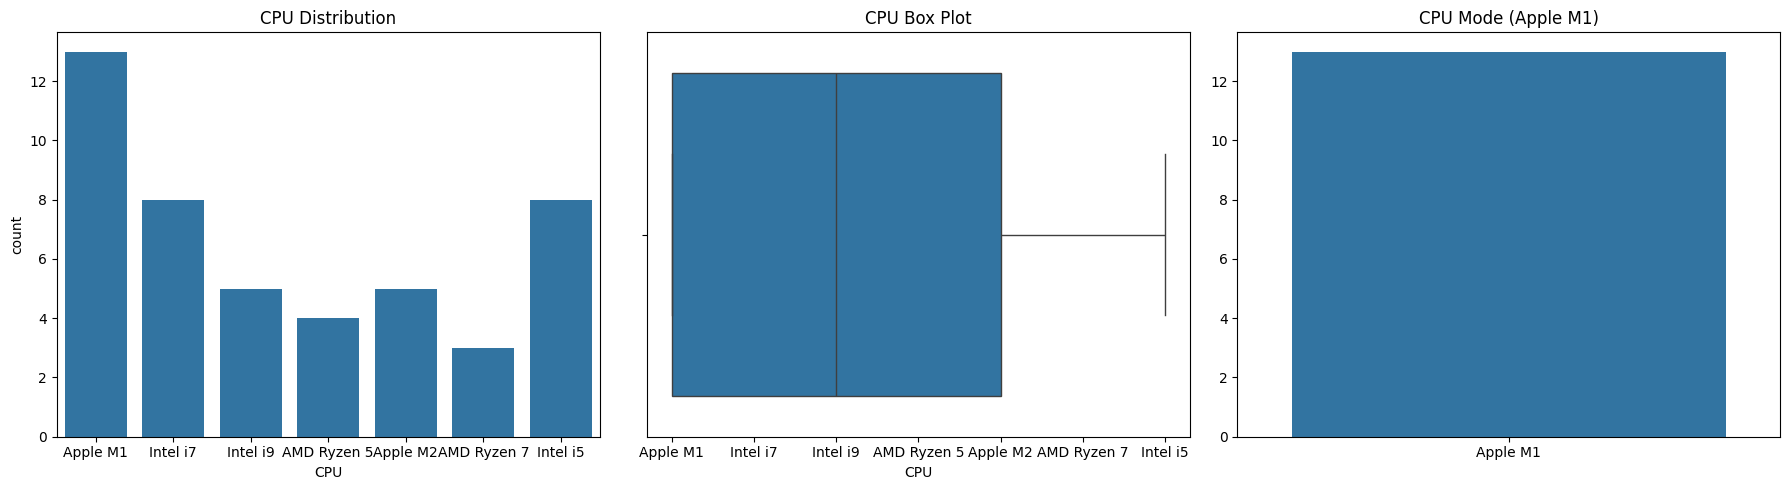

In [455]:

plt.figure(figsize=(18,5))

# 1. Distribution (Countplot since CPU is categorical)
plt.subplot(1,3,1)
sns.countplot(x=df["CPU"])
plt.title("CPU Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(1,3,2)
sns.boxplot(x=df["CPU"])
plt.title("CPU Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(1,3,3)
mode_val = df["CPU"].mode()[0]
sns.barplot(x=[mode_val], y=[df["CPU"].value_counts()[mode_val]])
plt.title(f"CPU Mode ({mode_val})")

plt.tight_layout()
plt.show()

In [456]:
cpu_mode = df["CPU"].mode()[0]
print(cpu_mode)

Apple M1


In [457]:
df["CPU"].fillna(cpu_mode, inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\100271364.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CPU"].fillna(cpu_mode, inplace=True)


In [458]:
df["CPU"].isnull().sum()

np.int64(0)

In [459]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        0
GPU                        5
Build_Quality              5
Display_Quality            4
Warranty                   0
Touchscreen                6
Backlit                    3
Fingerprint                6
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Handling Missing Values for (GPU)

In [460]:
df["GPU"].iloc[7:10]

7    Intel Integrated
8                 NaN
9    Intel Integrated
Name: GPU, dtype: object

In [461]:
gpu_mode = df["GPU"].mode()[0]
print(gpu_mode)

NVIDIA RTX 4060


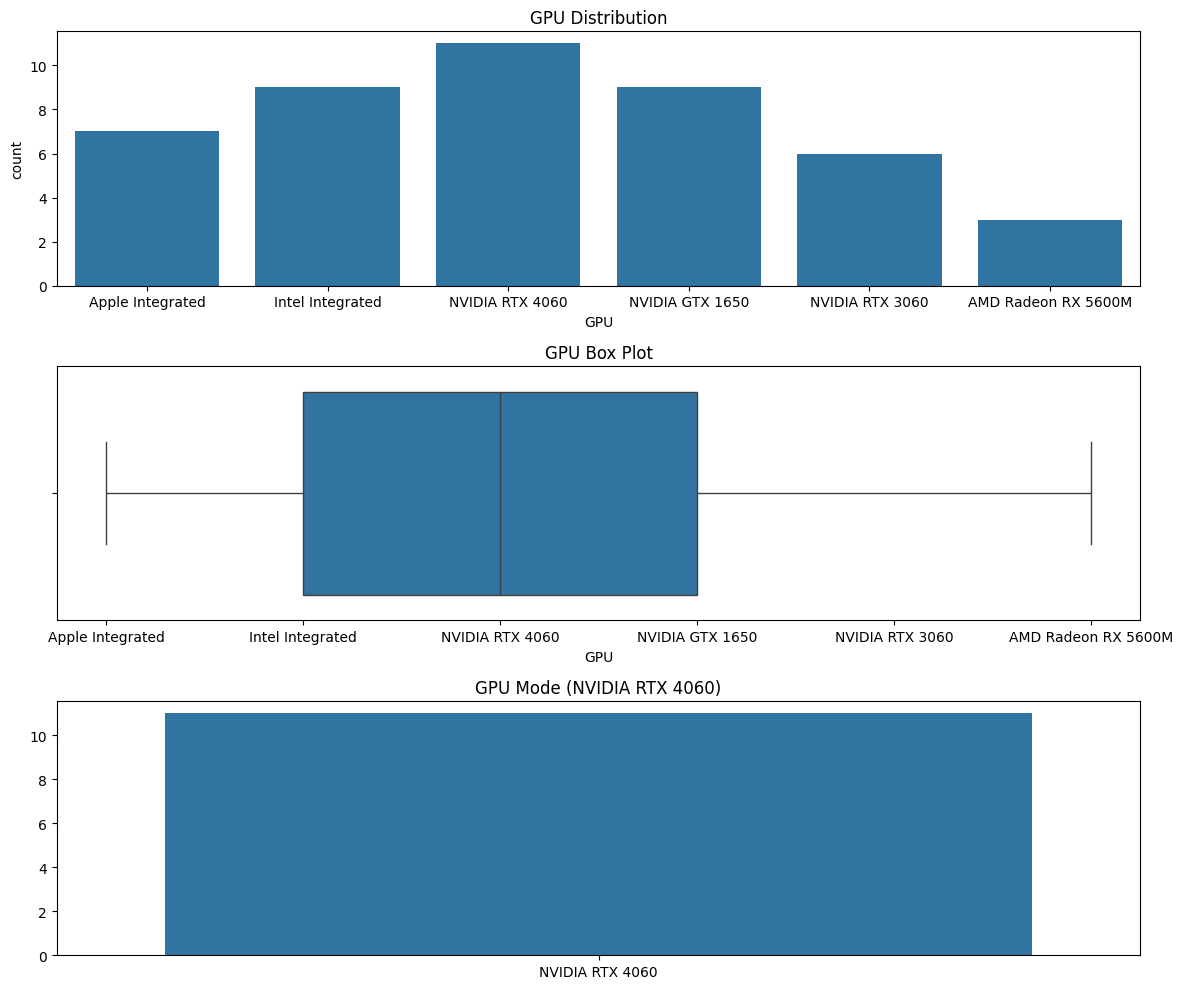

In [462]:

plt.figure(figsize=(12,10))

# 1. Distribution (Countplot since CPU is categorical)
plt.subplot(3,1,1)
sns.countplot(x=df["GPU"])
plt.title("GPU Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(3,1,2)
sns.boxplot(x=df["GPU"])
plt.title("GPU Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(3,1,3)
mode_val = df["GPU"].mode()[0]
sns.barplot(x=[mode_val], y=[df["GPU"].value_counts()[mode_val]])
plt.title(f"GPU Mode ({mode_val})")

plt.tight_layout()
plt.show()

In [463]:
df["GPU"].fillna(gpu_mode, inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\3519626465.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GPU"].fillna(gpu_mode, inplace=True)


In [464]:
df["GPU"].isnull().sum()

np.int64(0)

In [465]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        0
GPU                        0
Build_Quality              5
Display_Quality            4
Warranty                   0
Touchscreen                6
Backlit                    3
Fingerprint                6
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Handling Missing Values for (Build_Quality)

In [466]:
df["Build_Quality"].iloc[10:18]

10         Poor
11          NaN
12         Good
13          NaN
14    Excellent
15         Good
16          NaN
17         Good
Name: Build_Quality, dtype: object

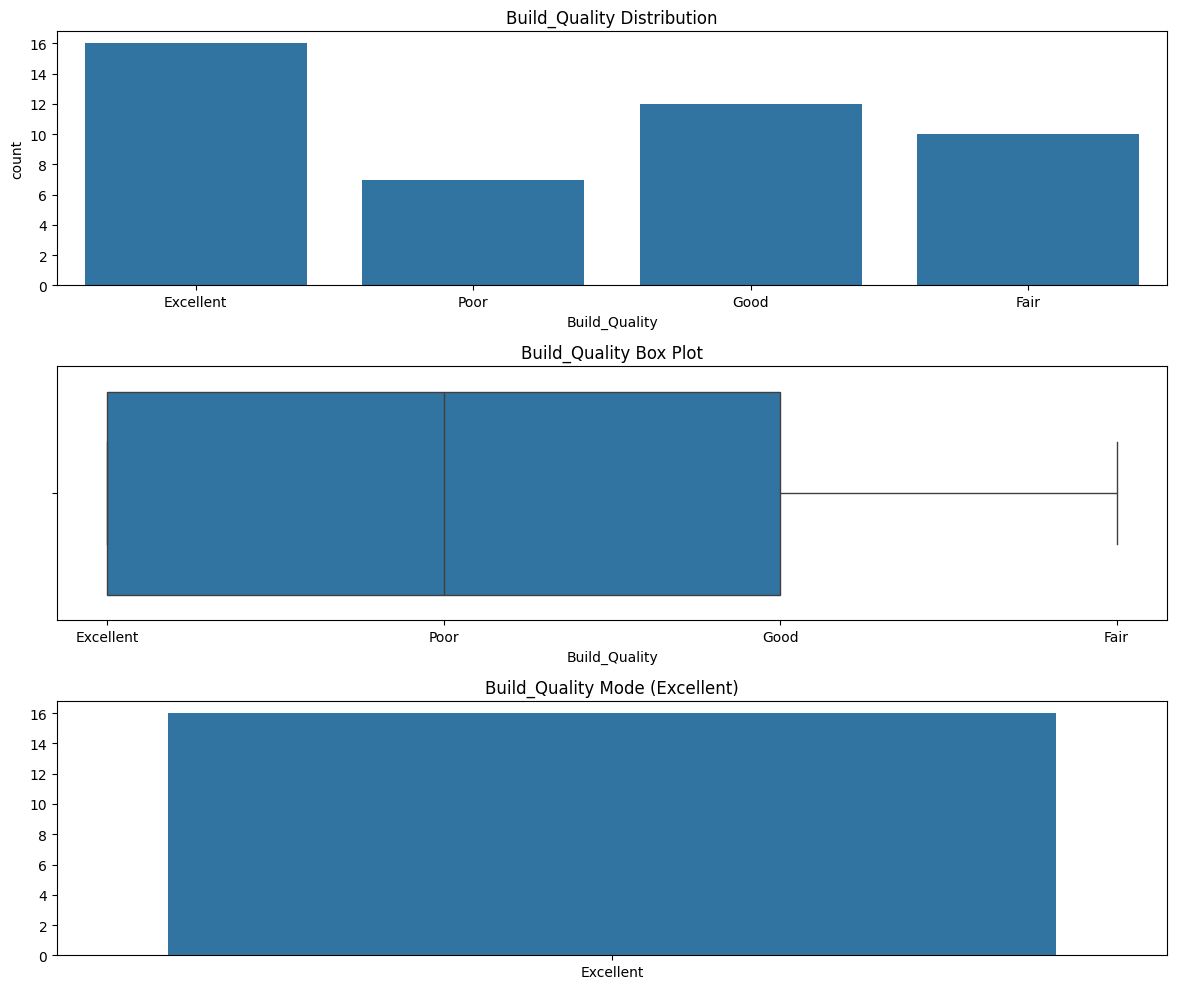

In [ ]:

plt.figure(figsize=(12,10))

# 1. Distribution (Countplot since Build_Quality is categorical)
plt.subplot(3,1,1)
sns.countplot(x=df["Build_Quality"])
plt.title("Build_Quality Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(3,1,2)
sns.boxplot(x=df["Build_Quality"])
plt.title("Build_Quality Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(3,1,3)
mode_val = df["Build_Quality"].mode()[0]
sns.barplot(x=[mode_val], y=[df["Build_Quality"].value_counts()[mode_val]])
plt.title(f"Build_Quality Mode ({mode_val})")

plt.tight_layout()
plt.show() 

In [468]:
bldQ_mode = df["Build_Quality"].mode()[0]
bldQ_mode

'Excellent'

In [469]:
df["Build_Quality"].fillna(bldQ_mode,inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\656681310.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Build_Quality"].fillna(bldQ_mode,inplace=True)


In [ ]:
df.isnull().sum() 

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        0
GPU                        0
Build_Quality              0
Display_Quality            4
Warranty                   0
Touchscreen                6
Backlit                    3
Fingerprint                6
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Handling Missing Values for (Display_Quality)

In [471]:
df["Display_Quality"].head()

0    Full HD
1         4K
2    Full HD
3        NaN
4         4K
Name: Display_Quality, dtype: object

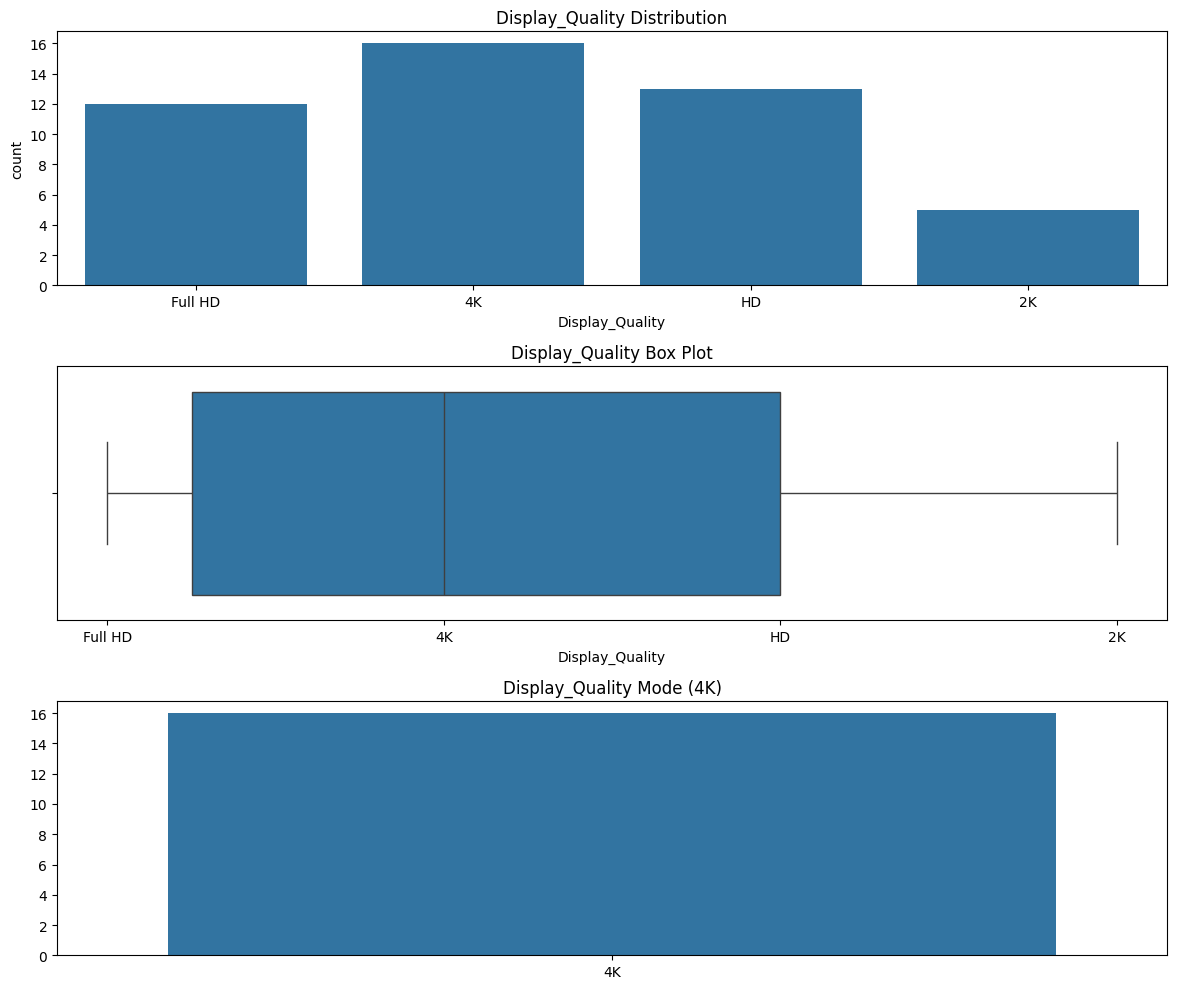

In [472]:

plt.figure(figsize=(12,10))

# 1. Distribution (Countplot since Display_Quality is categorical)
plt.subplot(3,1,1)
sns.countplot(x=df["Display_Quality"])
plt.title("Display_Quality Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(3,1,2)
sns.boxplot(x=df["Display_Quality"])
plt.title("Display_Quality Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(3,1,3)
mode_val = df["Display_Quality"].mode()[0]
sns.barplot(x=[mode_val], y=[df["Display_Quality"].value_counts()[mode_val]])
plt.title(f"Display_Quality Mode ({mode_val})")

plt.tight_layout()
plt.show()

In [473]:
disQ_mode = df["Display_Quality"].mode()[0]
disQ_mode

'4K'

In [474]:
df["Display_Quality"].fillna(disQ_mode, inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\385908065.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Display_Quality"].fillna(disQ_mode, inplace=True)


In [475]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        0
GPU                        0
Build_Quality              0
Display_Quality            0
Warranty                   0
Touchscreen                6
Backlit                    3
Fingerprint                6
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Handling Missing Values for (Touchscreen)

In [476]:
df["Touchscreen"].head()

0    Yes
1    Yes
2    NaN
3     No
4    Yes
Name: Touchscreen, dtype: object

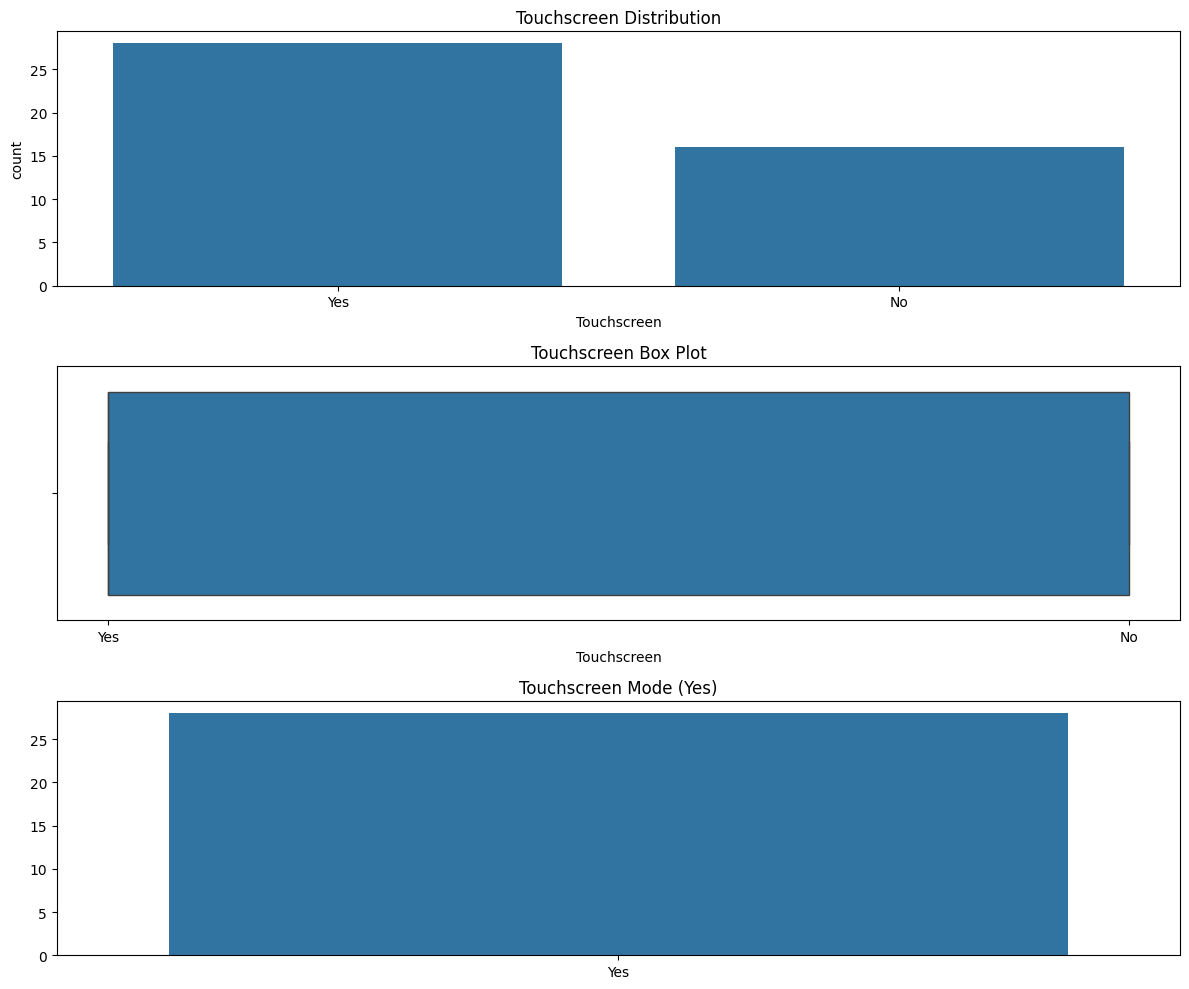

In [477]:

plt.figure(figsize=(12,10))

# 1. Distribution (Countplot since Touchscreen is categorical)
plt.subplot(3,1,1)
sns.countplot(x=df["Touchscreen"])
plt.title("Touchscreen Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(3,1,2)
sns.boxplot(x=df["Touchscreen"])
plt.title("Touchscreen Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(3,1,3)
mode_val = df["Touchscreen"].mode()[0]
sns.barplot(x=[mode_val], y=[df["Touchscreen"].value_counts()[mode_val]])
plt.title(f"Touchscreen Mode ({mode_val})")

plt.tight_layout()
plt.show()

In [478]:
touch_mode = df["Touchscreen"].mode()[0]

touch_mode


'Yes'

In [479]:
df["Touchscreen"].fillna(touch_mode,inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\3986378416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Touchscreen"].fillna(touch_mode,inplace=True)


In [480]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        0
GPU                        0
Build_Quality              0
Display_Quality            0
Warranty                   0
Touchscreen                0
Backlit                    3
Fingerprint                6
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Handling Missing Values for (Fingerprint)

In [481]:
df["Fingerprint"].iloc[5:10]

5     No
6     No
7    NaN
8     No
9    NaN
Name: Fingerprint, dtype: object

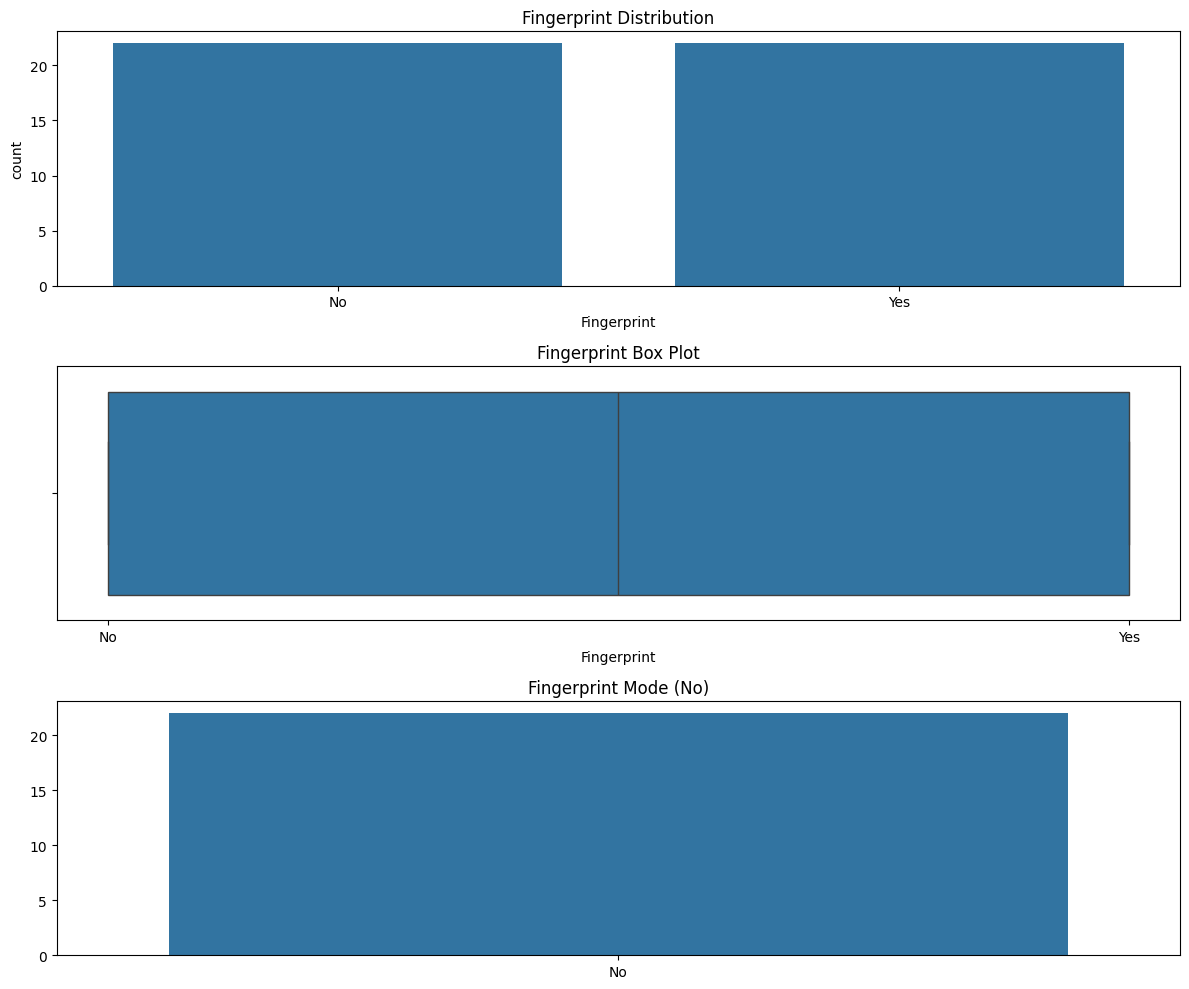

In [482]:

plt.figure(figsize=(12,10))

# 1. Distribution (Countplot since Fingerprint is categorical)
plt.subplot(3,1,1)
sns.countplot(x=df["Fingerprint"])
plt.title("Fingerprint Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(3,1,2)
sns.boxplot(x=df["Fingerprint"])
plt.title("Fingerprint Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(3,1,3)
mode_val = df["Fingerprint"].mode()[0]
sns.barplot(x=[mode_val], y=[df["Fingerprint"].value_counts()[mode_val]])
plt.title(f"Fingerprint Mode ({mode_val})")

plt.tight_layout()
plt.show()

In [483]:
fg_mode = df["Fingerprint"].mode()[0]
fg_mode

'No'

In [484]:
df["Fingerprint"].fillna(fg_mode, inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\1449079339.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Fingerprint"].fillna(fg_mode, inplace=True)


In [485]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        0
GPU                        0
Build_Quality              0
Display_Quality            0
Warranty                   0
Touchscreen                0
Backlit                    3
Fingerprint                0
Color                      7
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Handling Missing Values for (Color)

In [486]:
df["Color"].head()

0     Grey
1    Black
2      NaN
3     Grey
4     Blue
Name: Color, dtype: object

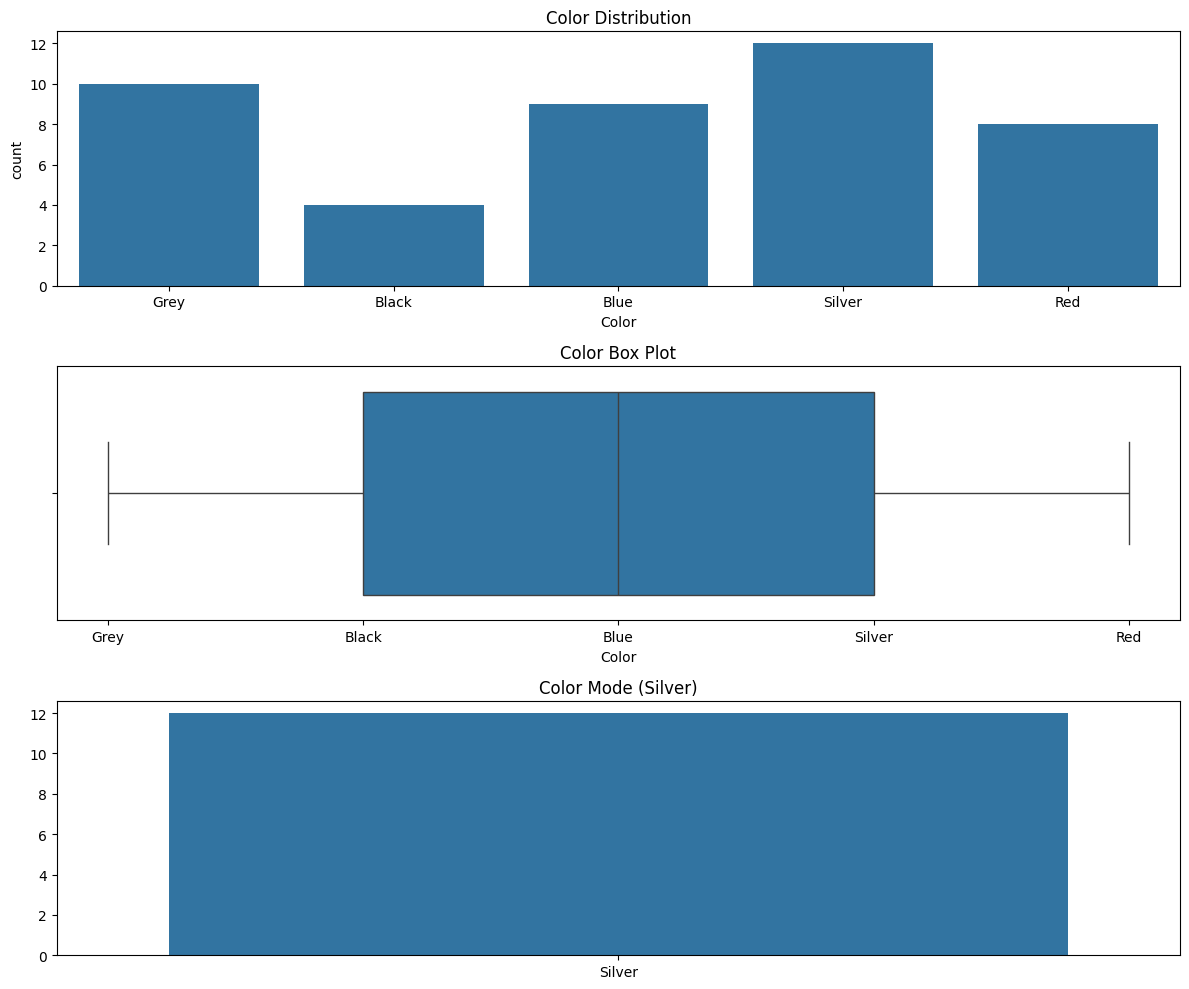

In [487]:

plt.figure(figsize=(12,10))

# 1. Distribution (Countplot since Color is categorical)
plt.subplot(3,1,1)
sns.countplot(x=df["Color"])
plt.title("Color Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(3,1,2)
sns.boxplot(x=df["Color"])
plt.title("Color Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(3,1,3)
mode_val = df["Color"].mode()[0]
sns.barplot(x=[mode_val], y=[df["Color"].value_counts()[mode_val]])
plt.title(f"Color Mode ({mode_val})")

plt.tight_layout()
plt.show()

In [488]:
color_mode = df["Color"].mode()[0]
color_mode

'Silver'

In [489]:
df["Color"].fillna(color_mode, inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\319841643.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Color"].fillna(color_mode, inplace=True)


In [490]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        0
GPU                        0
Build_Quality              0
Display_Quality            0
Warranty                   0
Touchscreen                0
Backlit                    3
Fingerprint                0
Color                      0
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Handling Missing Values (Backlit)

In [491]:
df["Backlit"].iloc[7:10]

7     No
8    NaN
9    Yes
Name: Backlit, dtype: object

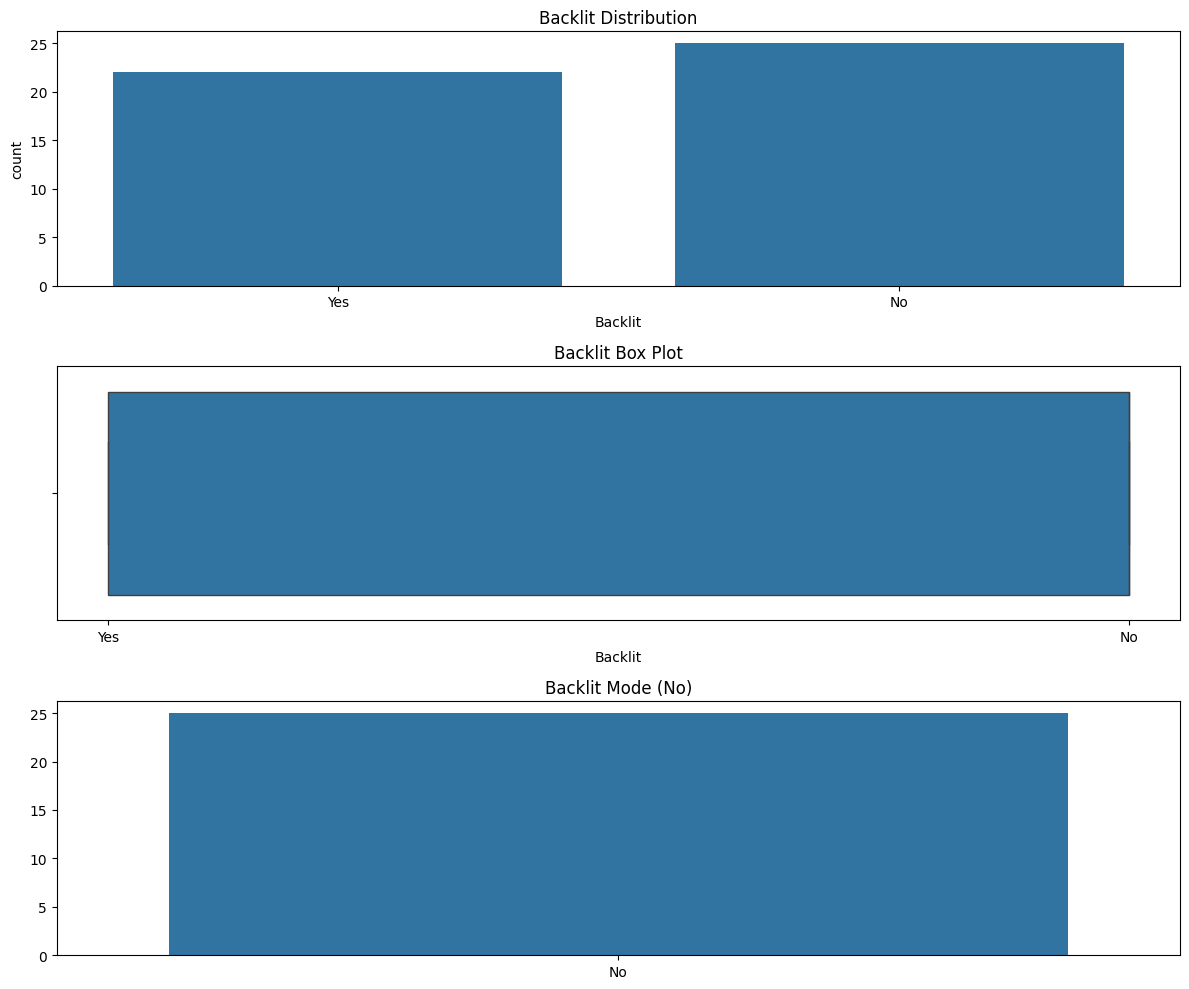

In [492]:

plt.figure(figsize=(12,10))

# 1. Distribution (Countplot since Backlit is categorical)
plt.subplot(3,1,1)
sns.countplot(x=df["Backlit"])
plt.title("Backlit Distribution")

# 2. Boxplot for Outliers (not meaningful for categories, but ok if numeric codes)
plt.subplot(3,1,2)
sns.boxplot(x=df["Backlit"])
plt.title("Backlit Box Plot")

# 3. Mode (show the most frequent OS as barplot)
plt.subplot(3,1,3)
mode_val = df["Backlit"].mode()[0]
sns.barplot(x=[mode_val], y=[df["Backlit"].value_counts()[mode_val]])
plt.title(f"Backlit Mode ({mode_val})")

plt.tight_layout()
plt.show()

In [493]:
bkl_mode = df["Backlit"].mode()[0]
bkl_mode

'No'

In [494]:
df["Backlit"].fillna(bkl_mode, inplace=True)


C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_12880\371344278.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Backlit"].fillna(bkl_mode, inplace=True)


In [495]:
df.isnull().sum()

Brand                      0
RAM                        0
Storage                    0
Weight                     0
Screen_Size                0
Battery_Life_(hours)       0
Operating_System           0
CPU                        0
GPU                        0
Build_Quality              0
Display_Quality            0
Warranty                   0
Touchscreen                0
Backlit                    0
Fingerprint                0
Color                      0
Pre-Installed_Softwares    7
Price                      0
dtype: int64

## Drop Unnessasary Columns (Pre-Installed_Softwares)

In [496]:
# Drop a single column
df.drop("Pre-Installed_Softwares", axis=1, inplace=True)

In [497]:
df.isnull().sum()

Brand                   0
RAM                     0
Storage                 0
Weight                  0
Screen_Size             0
Battery_Life_(hours)    0
Operating_System        0
CPU                     0
GPU                     0
Build_Quality           0
Display_Quality         0
Warranty                0
Touchscreen             0
Backlit                 0
Fingerprint             0
Color                   0
Price                   0
dtype: int64

In [498]:
df.head()

,Brand,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Operating_System,CPU,GPU,Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price
0,Apple,32.0,1024.0,2.67,13.3,8,macOS,Apple M1,Apple Integrated,Excellent,Full HD,3,Yes,Yes,No,Grey,2145.6
1,Lenovo,32.0,256.0,2.03,13.3,6,macOS,Intel i7,Intel Integrated,Poor,4K,2,Yes,Yes,Yes,Black,1633.4
2,Dell,8.0,512.0,1.30,17.0,4,macOS,Intel i9,NVIDIA RTX 4060,Good,Full HD,1,Yes,Yes,No,Silver,1619.8
3,Apple,8.0,1024.0,2.05,14.0,10,macOS,Apple M1,Apple Integrated,Fair,4K,1,No,Yes,Yes,Grey,1724.6
4,Dell,8.0,512.0,1.43,17.0,8,Windows,AMD Ryzen 5,NVIDIA RTX 4060,Poor,4K,3,Yes,Yes,Yes,Blue,1707.8


In [499]:
df.columns

Index(['Brand', 'RAM', 'Storage', 'Weight', 'Screen_Size',
       'Battery_Life_(hours)', 'Operating_System', 'CPU', 'GPU',
       'Build_Quality', 'Display_Quality', 'Warranty', 'Touchscreen',
       'Backlit', 'Fingerprint', 'Color', 'Price'],
      dtype='object')

## Encoding

### Label, One Hot Encoding , Binary Encoding
Example with Condition = {Excellent, Good, Fair, Poor}:

1. Label Encoding → {Excellent=3, Good=2, Fair=1, Poor=0} (order matters).
2. One-Hot → 4 new columns (Excellent, Good, Fair, Poor).
3. Dummy Variables → 3 columns only (drop one).
4. Binary → If only “Good” or “Bad” → {Good=1, Bad=0}.

    Brand
    One-Hot Encoding

In [500]:
brand_encoded = pd.get_dummies(df["Brand"], prefix="Brand", drop_first=True) 
df = pd.concat([df, brand_encoded], axis=1)
df.drop("Brand", axis=1, inplace=True) # drop the original column


In [501]:
df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Operating_System,CPU,GPU,Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI
0,32.0,1024.0,2.67,13.3,8,macOS,Apple M1,Apple Integrated,Excellent,Full HD,3,Yes,Yes,No,Grey,2145.6,True,False,False,False,False,False
1,32.0,256.0,2.03,13.3,6,macOS,Intel i7,Intel Integrated,Poor,4K,2,Yes,Yes,Yes,Black,1633.4,False,False,False,False,True,False
2,8.0,512.0,1.30,17.0,4,macOS,Intel i9,NVIDIA RTX 4060,Good,Full HD,1,Yes,Yes,No,Silver,1619.8,False,False,True,False,False,False
3,8.0,1024.0,2.05,14.0,10,macOS,Apple M1,Apple Integrated,Fair,4K,1,No,Yes,Yes,Grey,1724.6,True,False,False,False,False,False
4,8.0,512.0,1.43,17.0,8,Windows,AMD Ryzen 5,NVIDIA RTX 4060,Poor,4K,3,Yes,Yes,Yes,Blue,1707.8,False,False,True,False,False,False


    Operating_System
    One Hot Encoding

In [502]:
df.Operating_System.unique()

array(['macOS', 'Windows', 'Linux'], dtype=object)

In [503]:
os_encoded = pd.get_dummies(df["Operating_System"], prefix="OS", drop_first=True) 
df = pd.concat([df, os_encoded], axis=1)
df.drop("Operating_System", axis=1, inplace=True) # drop the original column


In [504]:
df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),CPU,GPU,Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS
0,32.0,1024.0,2.67,13.3,8,Apple M1,Apple Integrated,Excellent,Full HD,3,Yes,Yes,No,Grey,2145.6,True,False,False,False,False,False,False,True
1,32.0,256.0,2.03,13.3,6,Intel i7,Intel Integrated,Poor,4K,2,Yes,Yes,Yes,Black,1633.4,False,False,False,False,True,False,False,True
2,8.0,512.0,1.30,17.0,4,Intel i9,NVIDIA RTX 4060,Good,Full HD,1,Yes,Yes,No,Silver,1619.8,False,False,True,False,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,Apple M1,Apple Integrated,Fair,4K,1,No,Yes,Yes,Grey,1724.6,True,False,False,False,False,False,False,True
4,8.0,512.0,1.43,17.0,8,AMD Ryzen 5,NVIDIA RTX 4060,Poor,4K,3,Yes,Yes,Yes,Blue,1707.8,False,False,True,False,False,False,True,False


    CPU
    One Hot Encoding
    

In [505]:
df.CPU.unique()

array(['Apple M1', 'Intel i7', 'Intel i9', 'AMD Ryzen 5', 'Apple M2',
       'AMD Ryzen 7', 'Intel i5'], dtype=object)

In [506]:
cpu_encoded = pd.get_dummies(df["CPU"], prefix="CPU", drop_first=True) 
df = pd.concat([df, cpu_encoded], axis=1)
df.drop("CPU", axis=1, inplace=True) # drop the original column
df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),GPU,Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9
0,32.0,1024.0,2.67,13.3,8,Apple Integrated,Excellent,Full HD,3,Yes,Yes,No,Grey,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False
1,32.0,256.0,2.03,13.3,6,Intel Integrated,Poor,4K,2,Yes,Yes,Yes,Black,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False
2,8.0,512.0,1.30,17.0,4,NVIDIA RTX 4060,Good,Full HD,1,Yes,Yes,No,Silver,1619.8,False,False,True,False,False,False,False,True,False,False,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,Apple Integrated,Fair,4K,1,No,Yes,Yes,Grey,1724.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False
4,8.0,512.0,1.43,17.0,8,NVIDIA RTX 4060,Poor,4K,3,Yes,Yes,Yes,Blue,1707.8,False,False,True,False,False,False,True,False,False,False,False,False,False,False


    GPU
    One Hot Encoding

In [507]:
gpu_encoded = pd.get_dummies(df["GPU"], prefix="GPU", drop_first=True) 
df = pd.concat([df, gpu_encoded], axis=1)
df.drop("GPU", axis=1, inplace=True) # drop the original column
df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060
0,32.0,1024.0,2.67,13.3,8,Excellent,Full HD,3,Yes,Yes,No,Grey,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
1,32.0,256.0,2.03,13.3,6,Poor,4K,2,Yes,Yes,Yes,Black,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False
2,8.0,512.0,1.30,17.0,4,Good,Full HD,1,Yes,Yes,No,Silver,1619.8,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,Fair,4K,1,No,Yes,Yes,Grey,1724.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,8.0,512.0,1.43,17.0,8,Poor,4K,3,Yes,Yes,Yes,Blue,1707.8,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


    Build_Quality
    Label Encoding / Ordinal Encoding

In [508]:
df.Build_Quality.unique()

array(['Excellent', 'Poor', 'Good', 'Fair'], dtype=object)

In [509]:
quality_mapping = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Excellent": 4
}

df["Build_Quality"] = df["Build_Quality"].map(quality_mapping)


In [510]:
df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060
0,32.0,1024.0,2.67,13.3,8,4,Full HD,3,Yes,Yes,No,Grey,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
1,32.0,256.0,2.03,13.3,6,1,4K,2,Yes,Yes,Yes,Black,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False
2,8.0,512.0,1.30,17.0,4,3,Full HD,1,Yes,Yes,No,Silver,1619.8,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,2,4K,1,No,Yes,Yes,Grey,1724.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,8.0,512.0,1.43,17.0,8,1,4K,3,Yes,Yes,Yes,Blue,1707.8,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


In [511]:
df.Display_Quality.unique()

array(['Full HD', '4K', 'HD', '2K'], dtype=object)

In [512]:
resolution_mapping = {
    "HD": 1,
    "Full HD": 2,
    "2K": 3,
    "4K": 4
}

df["Display_Quality"] = df["Display_Quality"].map(resolution_mapping)


In [513]:
df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060
0,32.0,1024.0,2.67,13.3,8,4,2,3,Yes,Yes,No,Grey,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
1,32.0,256.0,2.03,13.3,6,1,4,2,Yes,Yes,Yes,Black,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False
2,8.0,512.0,1.30,17.0,4,3,2,1,Yes,Yes,No,Silver,1619.8,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,2,4,1,No,Yes,Yes,Grey,1724.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,8.0,512.0,1.43,17.0,8,1,4,3,Yes,Yes,Yes,Blue,1707.8,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


    Touchscreen
    Binary Encoding
    

In [514]:
# If values are Yes/No
df["Touchscreen"] = df["Touchscreen"].map({"Yes": 1, "No": 0})

# If values are True/False
df["Touchscreen"] = df["Touchscreen"].astype(int)

df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060
0,32.0,1024.0,2.67,13.3,8,4,2,3,1,Yes,No,Grey,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
1,32.0,256.0,2.03,13.3,6,1,4,2,1,Yes,Yes,Black,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False
2,8.0,512.0,1.30,17.0,4,3,2,1,1,Yes,No,Silver,1619.8,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,2,4,1,0,Yes,Yes,Grey,1724.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,8.0,512.0,1.43,17.0,8,1,4,3,1,Yes,Yes,Blue,1707.8,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


    Backlit
    Binary Encoding

In [515]:
# If values are Yes/No
df["Backlit"] = df["Backlit"].map({"Yes": 1, "No": 0})

# If values are True/False
df["Backlit"] = df["Backlit"].astype(int)

df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060
0,32.0,1024.0,2.67,13.3,8,4,2,3,1,1,No,Grey,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
1,32.0,256.0,2.03,13.3,6,1,4,2,1,1,Yes,Black,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False
2,8.0,512.0,1.30,17.0,4,3,2,1,1,1,No,Silver,1619.8,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,2,4,1,0,1,Yes,Grey,1724.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,8.0,512.0,1.43,17.0,8,1,4,3,1,1,Yes,Blue,1707.8,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


In [516]:
# Show all columns without "..."
pd.set_option("display.max_columns", None)

In [517]:
df.head(2)

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060
0,32.0,1024.0,2.67,13.3,8,4,2,3,1,1,No,Grey,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
1,32.0,256.0,2.03,13.3,6,1,4,2,1,1,Yes,Black,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False


    Fingerprint
    Binary Encoding

In [518]:
# If values are Yes/No
df["Fingerprint"] = df["Fingerprint"].map({"Yes": 1, "No": 0})

# If values are True/False
df["Fingerprint"] = df["Fingerprint"].astype(int)

df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Color,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060
0,32.0,1024.0,2.67,13.3,8,4,2,3,1,1,0,Grey,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
1,32.0,256.0,2.03,13.3,6,1,4,2,1,1,1,Black,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False
2,8.0,512.0,1.30,17.0,4,3,2,1,1,1,0,Silver,1619.8,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,2,4,1,0,1,1,Grey,1724.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,8.0,512.0,1.43,17.0,8,1,4,3,1,1,1,Blue,1707.8,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


In [519]:
color_encoded = pd.get_dummies(df["Color"], prefix="Color", drop_first=True)
df = pd.concat([df, color_encoded], axis=1)
df.drop("Color", axis=1, inplace=True)
df.head()


,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060,Color_Blue,Color_Grey,Color_Red,Color_Silver
0,32.0,1024.0,2.67,13.3,8,4,2,3,1,1,0,2145.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
1,32.0,256.0,2.03,13.3,6,1,4,2,1,1,1,1633.4,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False
2,8.0,512.0,1.30,17.0,4,3,2,1,1,1,0,1619.8,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True
3,8.0,1024.0,2.05,14.0,10,2,4,1,0,1,1,1724.6,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
4,8.0,512.0,1.43,17.0,8,1,4,3,1,1,1,1707.8,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False


## Convert all columns to int

In [520]:
df = df.astype(int)

In [521]:
df.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060,Color_Blue,Color_Grey,Color_Red,Color_Silver
0,32,1024,2,13,8,4,2,3,1,1,0,2145,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
1,32,256,2,13,6,1,4,2,1,1,1,1633,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
2,8,512,1,17,4,3,2,1,1,1,0,1619,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1
3,8,1024,2,14,10,2,4,1,0,1,1,1724,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
4,8,512,1,17,8,1,4,3,1,1,1,1707,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0


## Feature Selecting
- Target Variable : y  ( Price )
- Input Variables: X all rest col

In [522]:
df.columns

Index(['RAM', 'Storage', 'Weight', 'Screen_Size', 'Battery_Life_(hours)',
       'Build_Quality', 'Display_Quality', 'Warranty', 'Touchscreen',
       'Backlit', 'Fingerprint', 'Price', 'Brand_Apple', 'Brand_Asus',
       'Brand_Dell', 'Brand_HP', 'Brand_Lenovo', 'Brand_MSI', 'OS_Windows',
       'OS_macOS', 'CPU_AMD Ryzen 7', 'CPU_Apple M1', 'CPU_Apple M2',
       'CPU_Intel i5', 'CPU_Intel i7', 'CPU_Intel i9', 'GPU_Apple Integrated',
       'GPU_Intel Integrated', 'GPU_NVIDIA GTX 1650', 'GPU_NVIDIA RTX 3060',
       'GPU_NVIDIA RTX 4060', 'Color_Blue', 'Color_Grey', 'Color_Red',
       'Color_Silver'],
      dtype='object')

In [523]:
y = df["Price"] # Target Variable
X = df.drop("Price", axis=1)

In [524]:
y.head()

0    2145
1    1633
2    1619
3    1724
4    1707
Name: Price, dtype: int64

In [525]:
X.head()

,RAM,Storage,Weight,Screen_Size,Battery_Life_(hours),Build_Quality,Display_Quality,Warranty,Touchscreen,Backlit,Fingerprint,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,OS_Windows,OS_macOS,CPU_AMD Ryzen 7,CPU_Apple M1,CPU_Apple M2,CPU_Intel i5,CPU_Intel i7,CPU_Intel i9,GPU_Apple Integrated,GPU_Intel Integrated,GPU_NVIDIA GTX 1650,GPU_NVIDIA RTX 3060,GPU_NVIDIA RTX 4060,Color_Blue,Color_Grey,Color_Red,Color_Silver
0,32,1024,2,13,8,4,2,3,1,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
1,32,256,2,13,6,1,4,2,1,1,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
2,8,512,1,17,4,3,2,1,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1
3,8,1024,2,14,10,2,4,1,0,1,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
4,8,512,1,17,8,1,4,3,1,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0


## 6. Train, Test, Split
-  Train-test split (80% train, 20% test)

In [526]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split

# # 1. Split first
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     shuffle=True
# )

# print("Train shape:", X_train.shape, y_train.shape)
# print("Test shape:", X_test.shape, y_test.shape)


# Feature Scaling

In [527]:
# # 2. Scale ONLY on training set, then apply to test set
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)  # fit+transform on train
# X_test_scaled = scaler.transform(X_test)        # only transform on test

## Model Selection & Training


In [528]:
# from sklearn.linear_model import LinearRegression

# model = LinearRegression()

# model.fit(X_train_scaled, y_train)
# y_pred = model.predict(X_test_scaled)



In [529]:
# # Evaluate
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# y_pred = model.predict(X_test_scaled)  # use scaled test set

# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("MSE:", mean_squared_error(y_test, y_pred))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
# print("R² Score:", r2_score(y_test, y_pred))
# print("Model Score:", model.score(X_test_scaled, y_test))


# EXP

In [530]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [531]:
from sklearn.model_selection import train_test_split

# Use the scaled features for splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,   # scaled features
    y,          # target (not scaled)
    test_size=0.2,     # 20% test, 80% train
    random_state=42,   # reproducibility
    shuffle=True       # shuffle before split
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (40, 34) (40,)
Test shape: (10, 34) (10,)


In [532]:
from sklearn.linear_model import LinearRegression

# Initialize model
model = LinearRegression()

# Train the model on training data
model.fit(X_train, y_train)

# Predictions on test data
y_pred = model.predict(X_test)

print("✅ Model training complete!")


✅ Model training complete!


In [533]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on test data
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)
print("Model Score:", model.score(X_test, y_test))


MAE: 291.9480377208589
MSE: 124117.97243889196
RMSE: 352.30380701731275
R² Score: 0.5532922312323727
Model Score: 0.5532922312323727


MAE: 291.94803772085936 
MSE: 124117.97243889193 
RMSE: 352.30380701731275 
R² Score: 0.5532922312323728 
Model Score: 0.5532922312323728

In [534]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# Define parameter grid
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
lasso_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Ridge Regression with GridSearchCV
ridge = Ridge()
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best Ridge R²:", ridge_grid.best_score_)

# Lasso Regression with GridSearchCV
lasso = Lasso(max_iter=5000)
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_)
print("Best Lasso R²:", lasso_grid.best_score_)


Best Ridge alpha: {'alpha': 10}
Best Ridge R²: 0.21773426557039252


c:\Users\aabidkhokhar\.conda\envs\global_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.320e+03, tolerance: 5.894e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\aabidkhokhar\.conda\envs\global_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.054e+03, tolerance: 4.714e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\aabidkhokhar\.conda\envs\global_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

Best Lasso alpha: {'alpha': 100}
Best Lasso R²: 0.16470046148184692


c:\Users\aabidkhokhar\.conda\envs\global_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.697e+03, tolerance: 4.714e+02
  model = cd_fast.enet_coordinate_descent(


In [535]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Lasso
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize Lasso model
lasso = Lasso(max_iter=5000)

# GridSearchCV for tuning alpha
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)

# Best hyperparameter
print("Best Lasso alpha:", lasso_grid.best_params_)

# Best cross-validated score
print("Best Cross-Validated R²:", lasso_grid.best_score_)

# Final model with best alpha
best_lasso = lasso_grid.best_estimator_

# Evaluate on test data
y_pred_lasso = best_lasso.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R² Score:", r2_score(y_test, y_pred_lasso))


c:\Users\aabidkhokhar\.conda\envs\global_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.320e+03, tolerance: 5.894e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\aabidkhokhar\.conda\envs\global_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.054e+03, tolerance: 4.714e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\aabidkhokhar\.conda\envs\global_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

Best Lasso alpha: {'alpha': 100}
Best Cross-Validated R²: 0.16470046148184692
MAE: 340.07533412582075
MSE: 151712.4754331875
RMSE: 389.50285677153573
R² Score: 0.4539780173387944


In [536]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

# Predict
y_pred_gbr = gbr.predict(X_test)

# Evaluate
print("Gradient Boosting:")
print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("MSE:", mean_squared_error(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("R² Score:", r2_score(y_test, y_pred_gbr))


Gradient Boosting:
MAE: 221.18903309689182
MSE: 58679.44036092976
RMSE: 242.23839571985644
R² Score: 0.7888092968238791
